In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import itertools
import math


import osmnx as ox
import networkx as nx



## Problem 4

In [2]:
osu = (40.00631486702341, -83.02826240290825)
one_mile = 1609
two_mile = one_mile * 2

G = ox.graph_from_point(osu, dist=two_mile, network_type="drive")

In [3]:
G.number_of_nodes(), G.number_of_edges()

(1867, 5097)

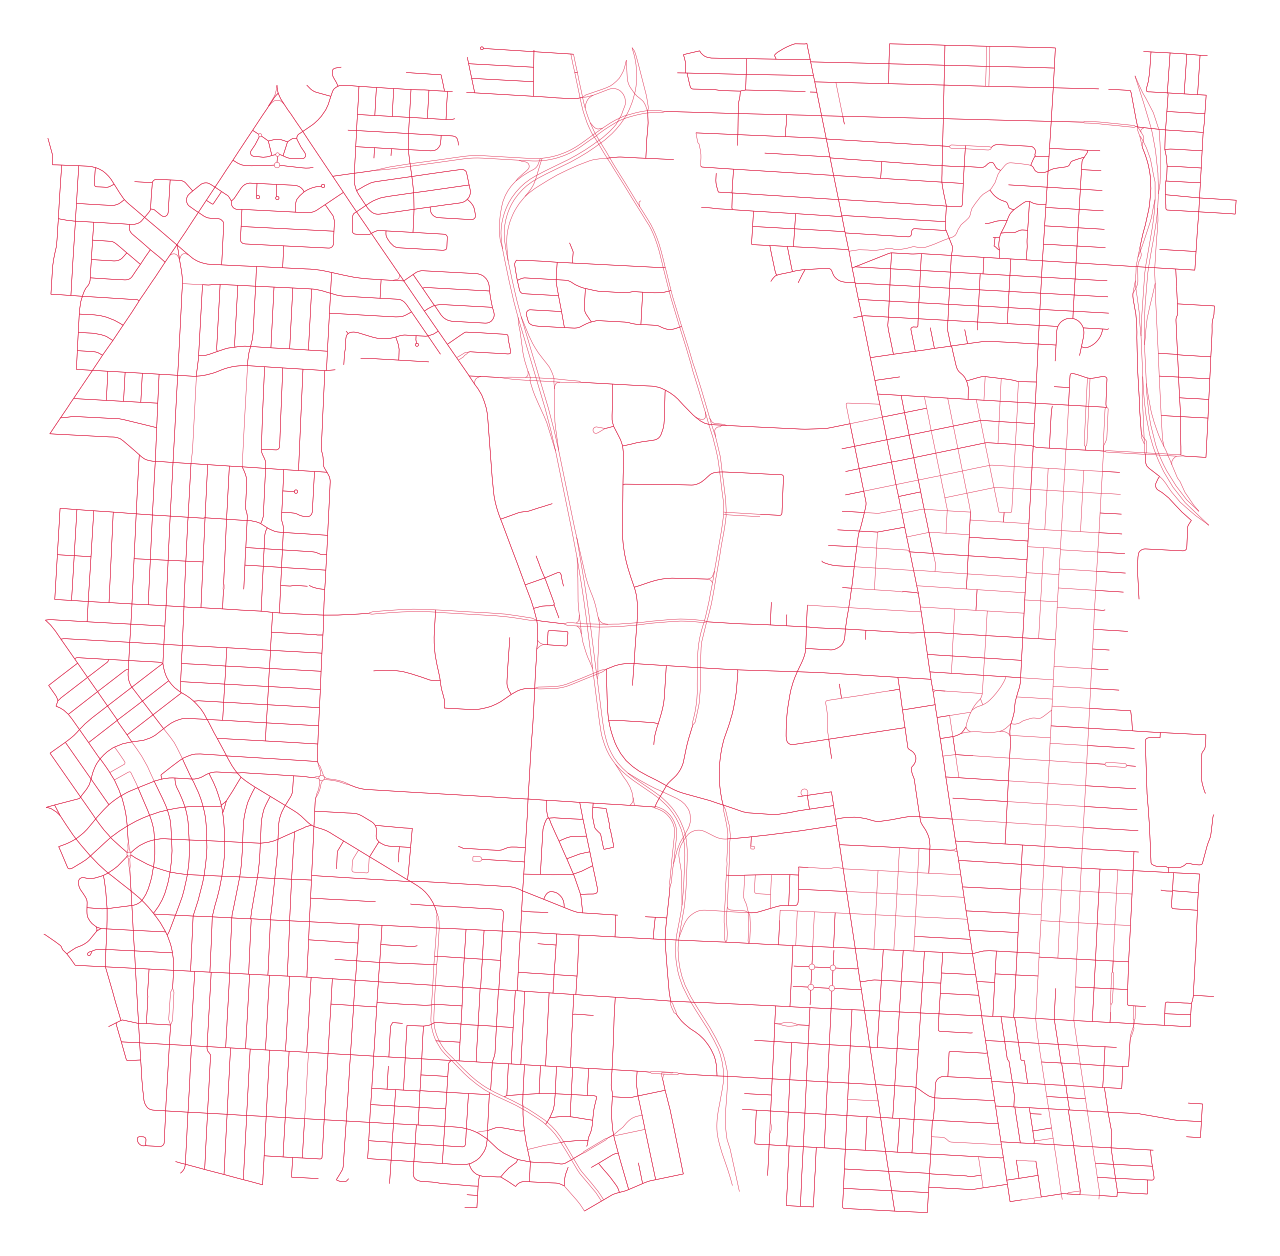

Text(0.5, 1.0, 'The Ohio State University\nN = 1867, M = 5097')

In [4]:
fig, ax = plt.subplots(1,1,figsize=(8, 8),dpi=200)
fig, ax = ox.plot_graph(G, ax=ax, bgcolor='white', node_color='orange', node_size=0,
              edge_linewidth=0.15, edge_color='crimson', save=True, filepath="figures/4_osu_map.png")
ax.set_title(f"The Ohio State University\nN = {G.number_of_nodes()}, M = {G.number_of_edges()}")


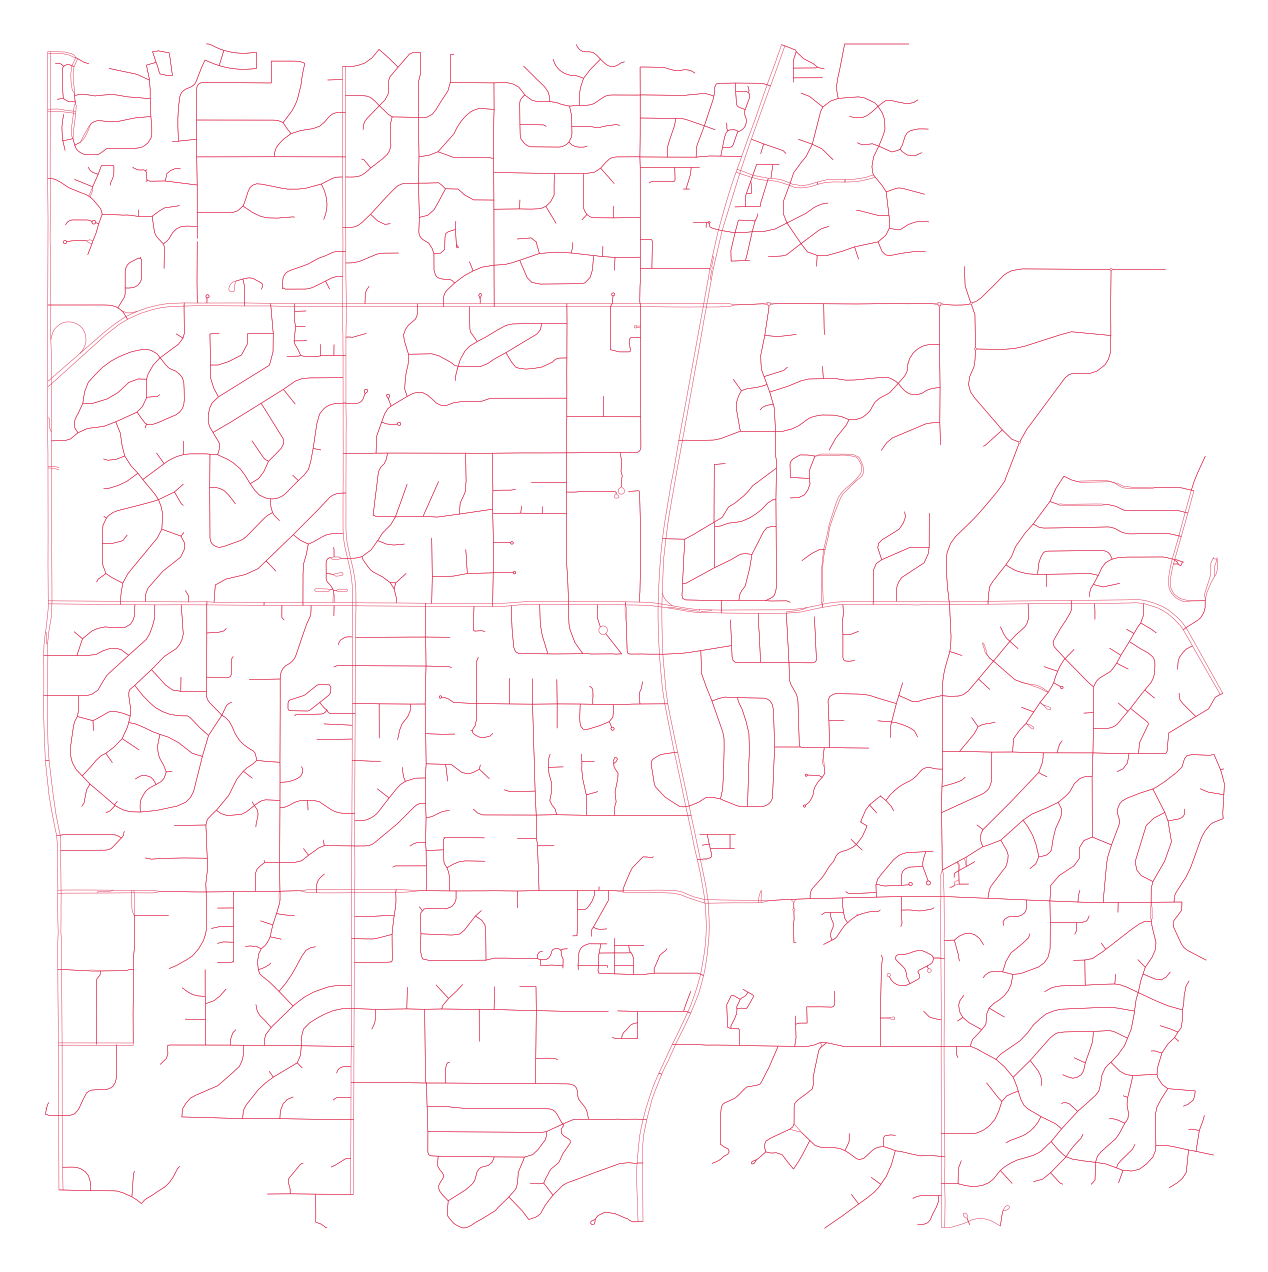

1584 3553


In [5]:
tucson = (32.335660407, -110.97908793)

G = ox.graph_from_point(tucson, dist=two_mile, network_type="drive")

fig, ax = plt.subplots(1,1,figsize=(8, 8),dpi=200)
fig, ax = ox.plot_graph(G, ax=ax, bgcolor='white', node_color='orange', node_size=0,
              edge_linewidth=0.15, edge_color='crimson', save=True, filepath="figures/4_tucson_map.png")
print(G.number_of_nodes(), G.number_of_edges())

In [14]:


def griddy(a, b, c):
    """
    how close to a right angle or straight line
    """
    ba = a - b
    bc = c - b

    
    cosine_angle = np.dot(ba, bc) / (np.linalg.norm(ba) * np.linalg.norm(bc))
    if np.isnan(cosine_angle):
        # print(f"\treturn 0")
        return 0
    else:
        arccos = np.arccos(cosine_angle)
        ret = np.cos(arccos * 4)
        # print(f"return {ret}")
        return ret


def griddyness(G):

    gness = 0
    angles = 0

    for node in G.nodes:
        # can't make an angle
        if G.degree[node] < 2:
            continue
        
        # get node neighbors and check all pairs
        for i, k in itertools.combinations(nx.neighbors(G, node), 2):

            a = np.array([G.nodes[i]["x"], G.nodes[i]["y"]])
            b = np.array([G.nodes[node]["x"], G.nodes[node]["y"]])
            c = np.array([G.nodes[k]["x"], G.nodes[k]["y"]])
            
            # how griddy is angle
            g = griddy(a, b, c)

            if np.isnan(g):
                continue

            # how far are the nodes in total
            dist = math.dist(a, b) + math.dist(b, c)

            # normalize by distance
            gness += g / (1 + dist)

            angles += 1

    # normalize by number of angles
    gness /= angles

    return gness


def road_network_distance(G, H):
    return math.fabs(griddyness(G) - griddyness(H))


In [7]:
city_names = ["Atlanta, Georgia, USA",
"Boston, MA, USA",
"Buffalo, NY, USA",
"Charlotte, NC, USA",
"Chicago, IL, USA",
"Cleveland, OH, USA",
"Dallas, TX, USA",
"Houston, TX, USA",
"Denver, CO, USA",
"Detroit, MI, USA",
"Las Vegas, NV, USA",
"Los Angeles, CA, USA",
"Manhattan, NYC, NY, USA",
"Miami, FL, USA",
"Minneapolis, MN, USA",
"Orlando, FL, USA",
"Philadelphia, PA, USA",
"Phoenix, AZ, USA",
"Portland, OR, USA",
"Sacramento, CA, USA",
"San Francisco, CA, USA",
"Seattle, WA, USA",
"St. Louis, MO, USA",
"Tampa, FL, USA",
"Washington, District of Columbia, USA"]

In [ ]:

city_dict = {}
for c in city_names:
    print(c)
    city_dict[c] = ox.graph_from_place(c, network_type="drive")



Atlanta, Georgia, USA
Boston, MA, USA
Buffalo, NY, USA
Charlotte, NC, USA
Chicago, IL, USA
Cleveland, OH, USA
Dallas, TX, USA
Houston, TX, USA
Denver, CO, USA
Detroit, MI, USA
Las Vegas, NV, USA
Los Angeles, CA, USA
Manhattan, NYC, NY, USA
Miami, FL, USA
Minneapolis, MN, USA
Orlando, FL, USA
Philadelphia, PA, USA
Phoenix, AZ, USA
Portland, OR, USA
Sacramento, CA, USA
San Francisco, CA, USA
Seattle, WA, USA
St. Louis, MO, USA
Tampa, FL, USA
Washington, District of Columbia, USA


In [15]:
griddyness(city_dict[city_names[0]])

/tmp/ipykernel_60303/1962957137.py:9: RuntimeWarning: invalid value encountered in scalar divide
  cosine_angle = np.dot(ba, bc) / (np.linalg.norm(ba) * np.linalg.norm(bc))
/tmp/ipykernel_60303/1962957137.py:14: RuntimeWarning: invalid value encountered in arccos
  arccos = np.arccos(cosine_angle)


np.float64(0.5130288936246553)

In [21]:
df = pd.DataFrame(index=city_names, columns=city_names).fillna(0)

for i, j in itertools.combinations(city_names, 2):
    print(i, j)
    G = city_dict[i]
    H = city_dict[j]

    dist = road_network_distance(G, H)
    print(dist)
    df.loc[i, j] = dist
    df.loc[j, i] = dist


df

Atlanta, Georgia, USA Boston, MA, USA


/tmp/ipykernel_60303/1962957137.py:9: RuntimeWarning: invalid value encountered in scalar divide
  cosine_angle = np.dot(ba, bc) / (np.linalg.norm(ba) * np.linalg.norm(bc))
/tmp/ipykernel_60303/1962957137.py:14: RuntimeWarning: invalid value encountered in arccos
  arccos = np.arccos(cosine_angle)


0.06920714669889583
Atlanta, Georgia, USA Buffalo, NY, USA
0.16917174076766262
Atlanta, Georgia, USA Charlotte, NC, USA
0.13349567646527577
Atlanta, Georgia, USA Chicago, IL, USA
0.3162201965722271
Atlanta, Georgia, USA Cleveland, OH, USA
0.16467600738365362
Atlanta, Georgia, USA Dallas, TX, USA
0.10913788926127432
Atlanta, Georgia, USA Houston, TX, USA
0.2167001249530478
Atlanta, Georgia, USA Denver, CO, USA
0.24287725404594573
Atlanta, Georgia, USA Detroit, MI, USA
0.24565079065117335
Atlanta, Georgia, USA Las Vegas, NV, USA
0.13394106163005692
Atlanta, Georgia, USA Los Angeles, CA, USA
0.1530066691659575
Atlanta, Georgia, USA Manhattan, NYC, NY, USA
0.07561631469825336
Atlanta, Georgia, USA Miami, FL, USA
0.3147818400382213
Atlanta, Georgia, USA Minneapolis, MN, USA
0.2607543185846719
Atlanta, Georgia, USA Orlando, FL, USA
0.12199707906102053
Atlanta, Georgia, USA Philadelphia, PA, USA
0.09602036520192403
Atlanta, Georgia, USA Phoenix, AZ, USA
0.13708856209217313
Atlanta, Georgia, U

,"Atlanta, Georgia, USA","Boston, MA, USA","Buffalo, NY, USA","Charlotte, NC, USA","Chicago, IL, USA","Cleveland, OH, USA","Dallas, TX, USA","Houston, TX, USA","Denver, CO, USA","Detroit, MI, USA",...,"Orlando, FL, USA","Philadelphia, PA, USA","Phoenix, AZ, USA","Portland, OR, USA","Sacramento, CA, USA","San Francisco, CA, USA","Seattle, WA, USA","St. Louis, MO, USA","Tampa, FL, USA","Washington, District of Columbia, USA"
"Atlanta, Georgia, USA",0,0.069207,0.169172,0.133496,0.31622,0.164676,0.109138,0.2167,0.242877,0.245651,...,0.121997,0.09602,0.137089,0.234187,0.064107,0.193724,0.049327,0.159627,0.303158,0.036552
"Boston, MA, USA",0.069207,0,0.238379,0.064289,0.385427,0.233883,0.178345,0.285907,0.312084,0.314858,...,0.191204,0.165228,0.206296,0.303394,0.133314,0.262932,0.118534,0.228834,0.372365,0.105759
"Buffalo, NY, USA",0.169172,0.238379,0,0.302667,0.147048,0.004496,0.060034,0.047528,0.073706,0.076479,...,0.047175,0.073151,0.032083,0.065015,0.105065,0.024553,0.119845,0.009545,0.133986,0.13262
"Charlotte, NC, USA",0.133496,0.064289,0.302667,0,0.449716,0.298172,0.242634,0.350196,0.376373,0.379146,...,0.255493,0.229516,0.270584,0.367682,0.197602,0.32722,0.182822,0.293122,0.436654,0.170047
"Chicago, IL, USA",0.31622,0.385427,0.147048,0.449716,0,0.151544,0.207082,0.09952,0.073343,0.070569,...,0.194223,0.2202,0.179132,0.082034,0.252113,0.122496,0.266894,0.156594,0.013062,0.279668
"Cleveland, OH, USA",0.164676,0.233883,0.004496,0.298172,0.151544,0,0.055538,0.052024,0.078201,0.080975,...,0.042679,0.068656,0.027587,0.069511,0.100569,0.029048,0.115349,0.005049,0.138482,0.128124
"Dallas, TX, USA",0.109138,0.178345,0.060034,0.242634,0.207082,0.055538,0,0.107562,0.133739,0.136513,...,0.012859,0.013118,0.027951,0.125049,0.045031,0.084587,0.059811,0.050489,0.19402,0.072586
"Houston, TX, USA",0.2167,0.285907,0.047528,0.350196,0.09952,0.052024,0.107562,0,0.026177,0.028951,...,0.094703,0.12068,0.079612,0.017487,0.152593,0.022976,0.167374,0.057074,0.086458,0.180148
"Denver, CO, USA",0.242877,0.312084,0.073706,0.376373,0.073343,0.078201,0.133739,0.026177,0,0.002774,...,0.12088,0.146857,0.105789,0.008691,0.178771,0.049153,0.193551,0.083251,0.060281,0.206326
"Detroit, MI, USA",0.245651,0.314858,0.076479,0.379146,0.070569,0.080975,0.136513,0.028951,0.002774,0,...,0.123654,0.14963,0.108562,0.011464,0.181544,0.051926,0.196324,0.086024,0.057507,0.209099


In [22]:
df.to_csv("cities.csv")

In [13]:
tucson = (32.335660407, -110.97908793)
osu = (40.00631486702341, -83.02826240290825)
one_mile = 1609
two_mile = one_mile * 2

G = ox.graph_from_point(osu, dist=two_mile, network_type="drive")
print(griddyness(G))
H = ox.graph_from_point(tucson, dist=two_mile, network_type="drive")
print(griddyness(H))

print(road_network_distance(G, H))




/tmp/ipykernel_60303/950546011.py:9: RuntimeWarning: invalid value encountered in scalar divide
  cosine_angle = np.dot(ba, bc) / (np.linalg.norm(ba) * np.linalg.norm(bc))


0.7054802640892698
0.397150403996383
0.30832986009288676


/tmp/ipykernel_60303/950546011.py:9: RuntimeWarning: invalid value encountered in scalar divide
  cosine_angle = np.dot(ba, bc) / (np.linalg.norm(ba) * np.linalg.norm(bc))
